**Mineral Water Recommender System ด้วย Graph** <br>แนวคิดคือ ผู้ใช้ดื่มหรือชอบน้ำแร่ยี่ห้อไหน → หา User คนอื่นที่ชอบน้ำแร่คล้ายกัน → ดูว่าคนเหล่านั้นชอบน้ำแร่ยี่ห้ออะไรอีก → แนะนำน้ำแร่ยี่ห้อนั้นกลับมา

ตัวอย่างสถานการณ์  มีผู้ใช้ 10 คน <br>

```
Kanya
Nattapong
Siriporn
Thanakrit
Preecha
Malee
Chaiyut
Nichada
Somsak
Ratree
```

และมีน้ำแร่ 7 ยี่ห้อ

```
Singha
Crystal
Minere
Nestle Pure Life
Perrier
Namthip
evian
```

สมมติข้อมูลความชอบคือ

```
Kanya     → Singha, Crystal

Nattapong → Singha, Crystal, Nestle Pure Life

Siriporn  → Singha, Minere

Thanakrit → Nestle Pure Life, Perrier

Preecha   → Crystal, Namthip

Malee     → Singha, Namthip, evian

Chaiyut   → Minere, Perrier

Nichada   → Singha, Crystal, evian

Somsak    → Namthip, Nestle Pure Life

Ratree    → Minere, Perrier, evian
```

รวมทั้งหมด 24 ความสัมพันธ์

**สร้างด้วย Python บน Google Colab**

In [ ]:
# ติดตั้งไลบรารี networkx สำหรับจัดการโครงสร้างข้อมูลแบบ Graph
!pip -q install networkx

In [ ]:
# networkx = ไลบรารีหลักที่ใช้สร้างและวิเคราะห์ Graph
import networkx as nx

# matplotlib = ใช้วาด Graph ออกมาเป็นรูปภาพ
import matplotlib.pyplot as plt

In [ ]:
# สร้าง Graph แบบไม่มีทิศทาง (Undirected Graph)
G = nx.Graph()

In [ ]:
# add user
# รายชื่อผู้ใช้ทั้ง 10 คน
users = [
    "Kanya",
    "Nattapong",
    "Siriporn",
    "Thanakrit",
    "Preecha",
    "Malee",
    "Chaiyut",
    "Nichada",
    "Somsak",
    "Ratree"
]

# วนเพิ่มผู้ใช้ทีละคนเข้าไปเป็น Node ใน Graph
for user in users:
    G.add_node(
        user,
 node_type="user"
    )

In [ ]:
# add waters
# รายชื่อน้ำแร่ทั้ง 7 ยี่ห้อ
waters = [
    "Singha",
    "Crystal",
    "Minere",
    "Nestle Pure Life",
    "Perrier",
    "Namthip",
    "evian"
]

# วนเพิ่มน้ำแร่ทีละยี่ห้อเข้าไปเป็น Node ใน Graph
for water in waters:
    G.add_node(
        water,
        # กำกับว่า Node นี้เป็นสินค้า ไม่ใช่ผู้ใช้
        node_type="water"
    )

In [ ]:
likes = [
    ("Kanya", "Singha"),
    ("Kanya", "Crystal"),

    ("Nattapong", "Singha"),
    ("Nattapong", "Crystal"),
    ("Nattapong", "Nestle Pure Life"),

    ("Siriporn", "Singha"),
    ("Siriporn", "Minere"),

    ("Thanakrit", "Nestle Pure Life"),
    ("Thanakrit", "Perrier"),

    ("Preecha", "Crystal"),
    ("Preecha", "Namthip"),

    ("Malee", "Singha"),
    ("Malee", "Namthip"),
    ("Malee", "evian"),

    ("Chaiyut", "Minere"),
    ("Chaiyut", "Perrier"),

    ("Nichada", "Singha"),
    ("Nichada", "Crystal"),
    ("Nichada", "evian"),

    ("Somsak", "Namthip"),
    ("Somsak", "Nestle Pure Life"),

    ("Ratree", "Minere"),
    ("Ratree", "Perrier"),
    ("Ratree", "evian")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

# ตรวจดูขนาดของ Graph
print("จำนวน Node ทั้งหมด:", G.number_of_nodes())
print("จำนวน Edge ทั้งหมด:", G.number_of_edges())

จำนวน Node ทั้งหมด: 17
จำนวน Edge ทั้งหมด: 24


วาด Graph

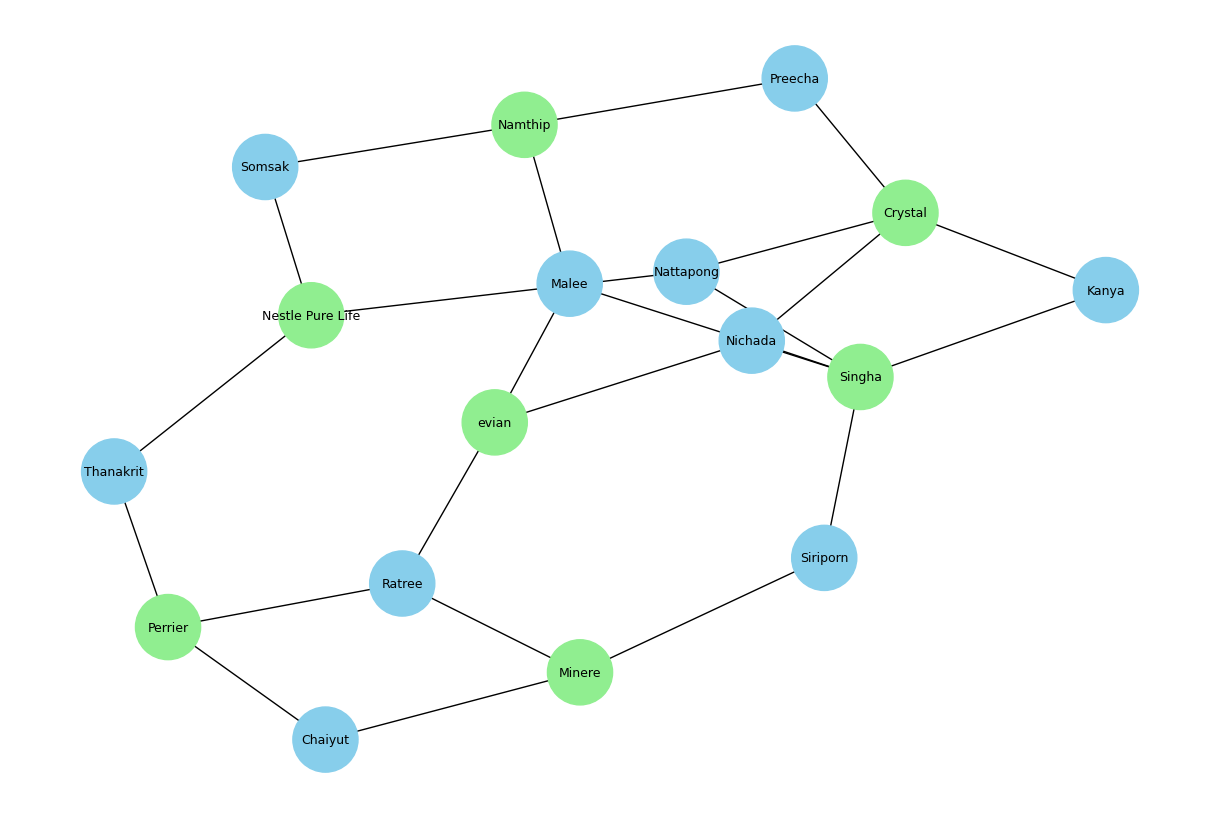

In [ ]:
# กำหนดขนาดรูป กว้าง 12 นิ้ว สูง 8 นิ้ว (ข้อมูลเยอะขึ้นต้องใช้พื้นที่มากขึ้น)
plt.figure(figsize=(12, 8))

# แยกสีระหว่าง Node สองประเภท
node_colors = [
    "skyblue" if G.nodes[n]["node_type"] == "user" else "lightgreen"
    for n in G.nodes()
]

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,      # แสดงชื่อกำกับบน Node
    node_color=node_colors,
    node_size=2200,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า Kanya ชอบน้ำแร่ยี่ห้ออะไรบ้าง?

In [ ]:
# G.neighbors() คืน Node ทั้งหมดที่มีเส้นเชื่อมตรงกับ Kanya
# ผลลัพธ์เป็น iterator จึงต้องครอบด้วย list() เพื่อให้พิมพ์ออกมาเห็นค่า
kanya_waters = list(
    G.neighbors("Kanya")
)

print(kanya_waters)

['Singha', 'Crystal']


ตรงนี้อธิบายได้ว่า Neighbor ของ Kanya คือ Node ที่เชื่อมกับ Kanya

คำถามที่ 2. หา User ที่ชอบน้ำแร่เหมือน Nattapong <br>
Nattapong ชอบ Singha, Crystal, Nestle Pure Life <br>
เราสามารถหาได้ว่าใครชอบน้ำแร่เหล่านี้เหมือนกัน

In [ ]:
# วนลูปสองชั้น
# ชั้นที่ 1 เดินจากคน ออกไปหาน้ำแร่ที่เขาชอบ
for water in G.neighbors("Nattapong"):

    print("Water:", water)

    # ชั้นที่ 2 เดินจากน้ำแร่ ย้อนกลับไปหาคนที่ชอบยี่ห้อเดียวกัน
    for user in G.neighbors(water):

        # ข้ามตัวเอง เพราะ Nattapong ก็เป็นเพื่อนบ้านของน้ำแร่ยี่ห้อนั้นด้วย
        if user != "Nattapong":
            print("  Similar user:", user)

Water: Singha
  Similar user: Kanya
  Similar user: Siriporn
  Similar user: Malee
  Similar user: Nichada
Water: Crystal
  Similar user: Kanya
  Similar user: Preecha
  Similar user: Nichada
Water: Nestle Pure Life
  Similar user: Thanakrit
  Similar user: Somsak


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Kanya
 ↓
น้ำแร่ที่ Kanya ชอบ
 ↓
User ที่ชอบน้ำแร่ยี่ห้อเดียวกัน
 ↓
น้ำแร่ยี่ห้ออื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Kanya
```

In [ ]:
from collections import Counter

target_user = "Kanya"

recommendations = Counter()

liked_waters = set(
    G.neighbors(target_user)
)


#ดูน้ำแร่แต่ละยี่ห้อที่ Kanya ชอบ
for water in liked_waters:

    #หา User ที่ชอบน้ำแร่ยี่ห้อเดียวกัน
    for similar_user in G.neighbors(water):

        # ข้ามตัวเอง กันไม่ให้เดินวนกลับมาที่ Kanya
        if similar_user == target_user:
            continue

        #ดูว่า User คนนั้นชอบน้ำแร่ยี่ห้ออะไรอีก
        for other_water in G.neighbors(similar_user):

            # คัดเฉพาะยี่ห้อที่ Kanya ยังไม่เคยชอบ
            # ถ้าไม่มีเงื่อนไขนี้ ผลลัพธ์จะเต็มไปด้วยของเดิมที่ชอบอยู่แล้ว
            if other_water not in liked_waters:

                # นับ 1 คะแนนต่อ 1 เส้นทางที่เดินมาถึงยี่ห้อนี้ได้
                recommendations[other_water] += 1


print(recommendations)

Counter({'evian': 3, 'Nestle Pure Life': 2, 'Namthip': 2, 'Minere': 1})


ผลลัพธ์คือ evian ได้ 3 คะแนน Nestle Pure Life และ Namthip ได้ 2 คะแนน ส่วน Minere ได้ 1 คะแนน <br>
คะแนนคือ **จำนวนเส้นทาง** ที่เดินไปถึงยี่ห้อนั้นได้ ไม่ใช่จำนวนคน ยี่ห้อที่เชื่อมถึงได้หลายทางจึงได้คะแนนสูงกว่า

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


def recommend_waters(G, target_user):
    """
    แนะนำน้ำแร่ให้ผู้ใช้ 1 คน โดยอาศัยความชอบของผู้ใช้คนอื่นที่มีรสนิยมคล้ายกัน

    พารามิเตอร์
        G           : Graph ที่มี Node เป็น user กับ water
        target_user : ชื่อผู้ใช้ที่ต้องการแนะนำ

    คืนค่า
        list ของ (ชื่อน้ำแร่, คะแนน) เรียงจากคะแนนมากไปน้อย
    """

    recommendations = Counter()

    # น้ำแร่ที่ผู้ใช้คนนี้ชอบอยู่แล้ว เก็บเป็น set เพื่อให้เช็กได้เร็ว
    liked_waters = set(
        G.neighbors(target_user)
    )

    # น้ำแร่ที่ผู้ใช้เป้าหมายชอบ
    for water in liked_waters:

        # ผู้ใช้คนอื่นที่ชอบยี่ห้อเดียวกัน
        for similar_user in G.neighbors(water):

            if similar_user == target_user:
                continue

            # ยี่ห้ออื่นที่ผู้ใช้คนนั้นชอบ
            for other_water in G.neighbors(similar_user):

                if other_water not in liked_waters:

                    recommendations[other_water] += 1

    # most_common() เรียงผลลัพธ์จากคะแนนมากไปน้อย
    return recommendations.most_common()

In [ ]:
# เรียกใช้งาน
result = recommend_waters(G, "Kanya")
print(result)

[('evian', 3), ('Nestle Pure Life', 2), ('Namthip', 2), ('Minere', 1)]


In [ ]:
# เรียกใช้งาน
result = recommend_waters(G, "Siriporn")
print(result)

[('evian', 3), ('Crystal', 3), ('Perrier', 2), ('Nestle Pure Life', 1), ('Namthip', 1)]


In [ ]:
# เรียกใช้งาน
result = recommend_waters(G, "Ratree")
print(result)

[('Singha', 3), ('Nestle Pure Life', 1), ('Namthip', 1), ('Crystal', 1)]


In [ ]:
# ลองเรียกให้ครบทุกคน เพื่อดูว่าฟังก์ชันใช้ได้กับผู้ใช้ทั้ง 10 คน
for user in users:

    result = recommend_waters(G, user)

    #ตัดมาแสดงเฉพาะ 3 อันดับแรก
    print(user, "→", result[:3])

Kanya → [('evian', 3), ('Nestle Pure Life', 2), ('Namthip', 2)]
Nattapong → [('Namthip', 3), ('evian', 3), ('Perrier', 1)]
Siriporn → [('evian', 3), ('Crystal', 3), ('Perrier', 2)]
Thanakrit → [('Minere', 2), ('Singha', 1), ('Crystal', 1)]
Preecha → [('Singha', 4), ('evian', 2), ('Nestle Pure Life', 2)]
Malee → [('Crystal', 5), ('Minere', 2), ('Nestle Pure Life', 2)]
Chaiyut → [('evian', 2), ('Nestle Pure Life', 1), ('Singha', 1)]
Nichada → [('Namthip', 3), ('Minere', 2), ('Nestle Pure Life', 2)]
Somsak → [('Singha', 2), ('Crystal', 2), ('Perrier', 1)]
Ratree → [('Singha', 3), ('Nestle Pure Life', 1), ('Namthip', 1)]


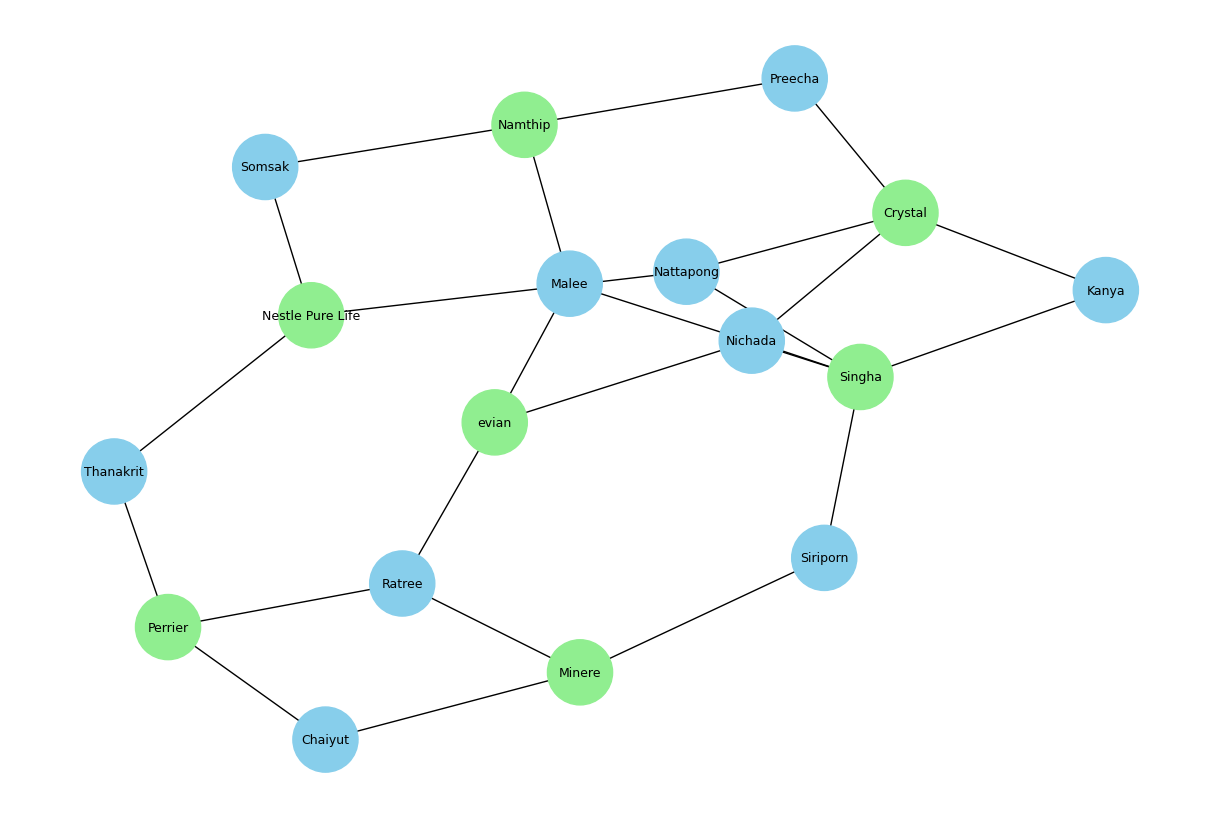

Recommendations for Malee
Crystal Score = 5
Minere Score = 2
Nestle Pure Life Score = 2
Perrier Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

# Undirected Graph เดินได้ทั้งสองทิศทาง
G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "Kanya",
    "Nattapong",
    "Siriporn",
    "Thanakrit",
    "Preecha",
    "Malee",
    "Chaiyut",
    "Nichada",
    "Somsak",
    "Ratree"
]

for user in users:

    # node_type="user" ใช้แยกประเภท Node
    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Waters
# ==================================

waters = [
    "Singha",
    "Crystal",
    "Minere",
    "Nestle Pure Life",
    "Perrier",
    "Namthip",
    "evian"
]

for water in waters:

    G.add_node(
        water,
        node_type="water"
    )


# ==================================
# 4. User-Water Relationships
# ==================================

# (ผู้ใช้, น้ำแร่ที่ชอบ) รวม 24 ความสัมพันธ์
likes = [

    ("Kanya", "Singha"),
    ("Kanya", "Crystal"),

    ("Nattapong", "Singha"),
    ("Nattapong", "Crystal"),
    ("Nattapong", "Nestle Pure Life"),

    ("Siriporn", "Singha"),
    ("Siriporn", "Minere"),

    ("Thanakrit", "Nestle Pure Life"),
    ("Thanakrit", "Perrier"),

    ("Preecha", "Crystal"),
    ("Preecha", "Namthip"),

    ("Malee", "Singha"),
    ("Malee", "Namthip"),
    ("Malee", "evian"),

    ("Chaiyut", "Minere"),
    ("Chaiyut", "Perrier"),

    ("Nichada", "Singha"),
    ("Nichada", "Crystal"),
    ("Nichada", "evian"),

    ("Somsak", "Namthip"),
    ("Somsak", "Nestle Pure Life"),

    ("Ratree", "Minere"),
    ("Ratree", "Perrier"),
    ("Ratree", "evian")

]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(12, 8)
)


# ระบายสี Node คนละสีตาม node_type
node_colors = [
    "skyblue" if G.nodes[n]["node_type"] == "user" else "lightgreen"
    for n in G.nodes()
]


# seed=42 ทำให้ตำแหน่ง Node เหมือนเดิมทุกครั้ง
pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2200,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_waters(
    G,
    target_user
):

    recommendations = Counter()

    # ของที่ชอบอยู่แล้ว ใช้ set เพื่อเช็กสมาชิกได้เร็ว
    liked_waters = set(
        G.neighbors(
            target_user
        )
    )

    # ระดับ 1 น้ำแร่ที่ผู้ใช้เป้าหมายชอบ
    for water in liked_waters:

        # ระดับ 2 คนอื่นที่ชอบยี่ห้อเดียวกัน
        for similar_user in G.neighbors(water):

            if similar_user == target_user:
                continue

            # ระดับ 3 ยี่ห้ออื่นที่คนนั้นชอบ
            for other_water in G.neighbors(
                similar_user
            ):

                # เอาเฉพาะยี่ห้อใหม่ที่ยังไม่เคยชอบ
                if other_water not in liked_waters:

                    recommendations[
                        other_water
                    ] += 1

    return recommendations.most_common()


# ==================================
# 7. Recommend for one user
# ==================================

target_user = "Malee"

result = recommend_waters(
    G,
    target_user
)


print(
    "Recommendations for",
    target_user
)


for water, score in result:

    print(
        water,
        "Score =",
        score
    )

```
เราจะสังเกตได้ว่า

Kanya และ Nichada ชอบ Singha และ Crystal เหมือนกัน

แต่ Nichada ยังชอบ

evian

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า Kanya กับ Nichada มีความชอบคล้ายกัน
และ Nichada ชอบ evian แต่ Kanya ยังไม่ได้เลือก evian
ระบบอาจแนะนำ evian ให้ Kanya

นี่คือ Recommender System แบบ Graph อย่างง่ายค่ะ
```